# Supplementary Figure S40: `s40_adversarial_robustness`

**Adversarial attack-method comparisons.** Validation that the adversarial-sensitivity probe used in the main analysis is stable across different methods of implementing adversarial attacks. (A) We plot the agreement between a single-step FGSM attack and a multi-step PGD attack across perturbation budgets $\epsilon$ (log-2 axis, $2^{-1}$ to $2^6$ over $255$). Here agreement varies as a function of perturbation magnitude, reaching a minimum of approximately $0.63$ at intermediate budgets while remaining substantially above zero throughout. Thus, FGSM and PGD yield broadly consistent rankings of readout sensitivity across the full range of perturbation strengths. (B) Normalized $L_\infty$ swing as a function of $\epsilon$ for untrained (gray), conventionally trained (crimson), and adversarially trained (green) model groups, shown separately for PGD (solid circles) and FGSM (dashed open squares). Across all perturbation budgets and for both attack methods, adversarially trained models show the lowest sensitivity, occupying a distinct low-swing regime relative to the other model groups. (C) The relationship between adversarial sensitivity and control is reproduced using FGSM. Horizontal bars show the correlation between adversarial sensitivity (log-$\epsilon$ AUC over $[0.125, 16]/255$, the main-figure measure) and the control slope, computed from site residuals and oriented such that the relationship across the full model set is positive, for PGD (blue) and FGSM (orange). Correlations are shown at both the model level (top: all $10$ models, $9$ trained models, and $7$ conventionally trained models) and the site level (bottom: $n = 250$, $225$, and $175$). FGSM reproduces the PGD relationship across the full model set and the subset of nine trained models. However, for both attacks, this relationship collapses toward zero when considering only the seven conventionally trained models, with a small sign reversal for FGSM. Thus, the sensitivity-control relationship is specifically driven by the inclusion of the two adversarially trained models.

Rendered by `figures/supplementary/sup_adversarial_robustness.py`; the PNG written below is pixel-identical to the manuscript file `s40_adversarial_robustness.png` in the reference environment (see docs/REPRODUCIBILITY.md). The preview shown here is downscaled.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
out_dir = paths.output_dir() / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
from figures.supplementary.sup_adversarial_robustness import main

# main() writes <out_dir>/<manuscript name>.png (border-trimmed, so it matches the submitted file)
# and returns its path; keyword arguments select the non-default variants documented in the script.
png = main(str(out_dir))
print(png)

Saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s40_adversarial_robustness.png
/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s40_adversarial_robustness.png


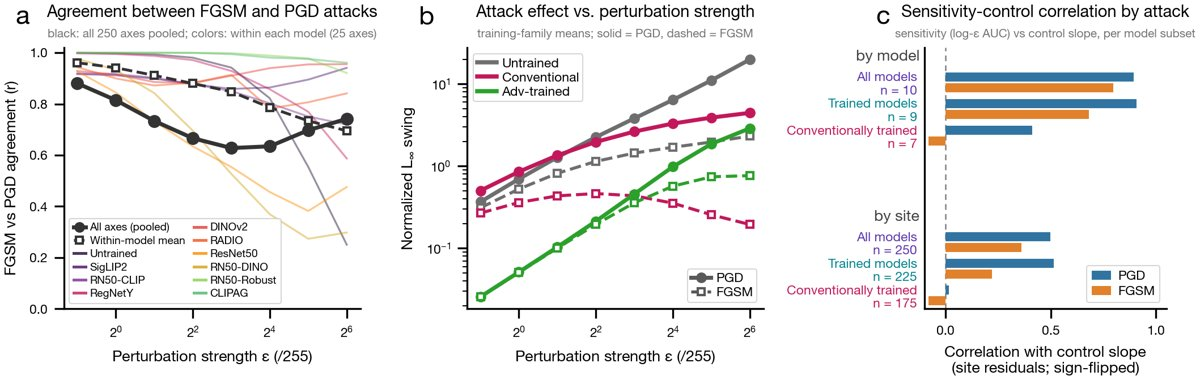

In [3]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# Show a downscaled JPEG preview (the full-resolution PNG can be tens of MB); open the file for detail.
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))